In [5]:
# 📓 01_data_preprocessing.ipynb
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress
# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

# Step 2: Load datasets
fraud_data = pd.read_csv('../data/Fraud_Data.csv')
ip_data = pd.read_csv('../data/IpAddress_to_Country.csv')
credit_data = pd.read_csv('../data/creditcard.csv')

# Step 3: Basic info
print("Fraud Data Info:")
display(fraud_data.info(), fraud_data.head())

print("\nIP Address Data Info:")
display(ip_data.info(), ip_data.head())

print("\nCredit Card Data Info:")
display(credit_data.info(), credit_data.head())

# Step 4: Check for missing values
print("\nMissing values in Fraud Data:")
print(fraud_data.isnull().sum())

print("\nMissing values in IP Data:")
print(ip_data.isnull().sum())

print("\nMissing values in Credit Card Data:")
print(credit_data.isnull().sum())


# Function to convert IP address to integer


Fraud Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


None

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0



IP Address Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 3.2+ MB


None

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China



Credit Card Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null 

None

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values in Fraud Data:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Missing values in IP Data:
lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64

Missing values in Credit Card Data:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
# Remove decimal and cast to integer
fraud_data['ip_int'] = fraud_data['ip_address'].astype(float).astype(int)
ip_data['lower_ip_int'] = ip_data['lower_bound_ip_address'].astype(float).astype(int)
ip_data['upper_ip_int'] = ip_data['upper_bound_ip_address'].astype(float).astype(int)
fraud_data.to_csv('../data/Fraud_Data_with_IP.csv', index=False)
print(fraud_data.columns)
fraud_data[['ip_address', 'ip_int']].head(10)


In [11]:
# Merge using a condition where fraud_data.ip_int is between lower and upper bounds of IP
def find_country(ip_int):
    row = ip_data[(ip_data['lower_ip_int'] <= ip_int) & (ip_data['upper_ip_int'] >= ip_int)]
    if not row.empty:
        return row.iloc[0]['country']
    else:
        return np.nan

# Map country to fraud_data
fraud_data['country'] = fraud_data['ip_int'].apply(find_country)


In [12]:
fraud_data['country'].value_counts(dropna=False)


country
United States     58049
NaN               21966
China             12038
Japan              7306
United Kingdom     4490
                  ...  
Yemen                 1
San Marino            1
Burundi               1
Nauru                 1
Guadeloupe            1
Name: count, Length: 182, dtype: int64

In [15]:
fraud_data['country'] = fraud_data['country'].fillna('Unknown')
fraud_data['country'].value_counts().head(10)
# Remove duplicates
fraud_data.drop_duplicates(inplace=True)
credit_data.drop_duplicates(inplace=True)

# Convert timestamps
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

# Check datatypes
print(fraud_data.dtypes)



user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value             int64
device_id                 object
source                    object
browser                   object
sex                       object
age                        int64
ip_address               float64
class                      int64
ip_int                     int64
country                   object
dtype: object


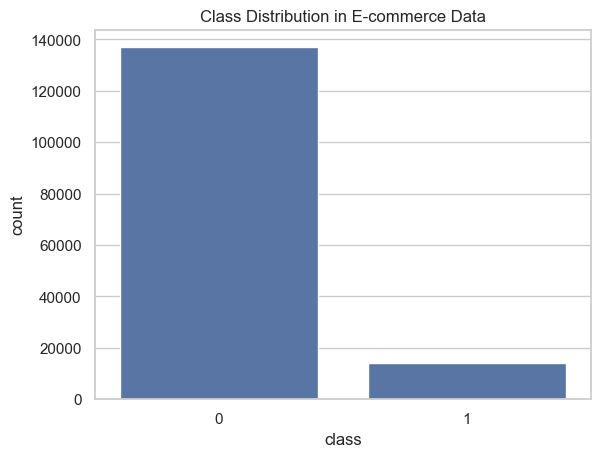

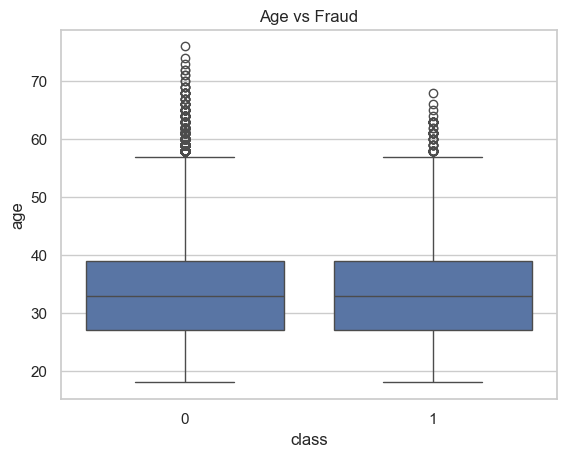

In [16]:
# Univariate: Fraud class distribution
sns.countplot(data=fraud_data, x='class')
plt.title('Class Distribution in E-commerce Data')
plt.show()

# Bivariate: Age vs Fraud
sns.boxplot(x='class', y='age', data=fraud_data)
plt.title('Age vs Fraud')
plt.show()


In [17]:
# Transaction frequency by user
user_tx_count = fraud_data.groupby('user_id').size().reset_index(name='transaction_count')
fraud_data = fraud_data.merge(user_tx_count, on='user_id', how='left')

# Time-based features
fraud_data['hour_of_day'] = fraud_data['purchase_time'].dt.hour
fraud_data['day_of_week'] = fraud_data['purchase_time'].dt.dayofweek
fraud_data['time_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds() / 3600  # in hours


In [18]:
fraud_data[['user_id', 'transaction_count']].head()
fraud_data['transaction_count'].describe()


count    151112.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: transaction_count, dtype: float64

In [20]:
fraud_data[['purchase_time', 'signup_time', 'hour_of_day', 'day_of_week', 'time_since_signup']].head()

# Summary stats
fraud_data[['hour_of_day', 'day_of_week', 'time_since_signup']].describe()


,hour_of_day,day_of_week,time_since_signup
count,151112.000000,151112.000000,151112.000000
mean,11.521593,3.011819,1370.008125
std,6.912474,2.006203,868.406422
min,0.000000,0.000000,0.000278
25%,6.000000,1.000000,607.431528
50%,12.000000,3.000000,1368.429306
75%,17.000000,5.000000,2123.479028
max,23.000000,6.000000,2879.992222


In [21]:
print(fraud_data['class'].value_counts(normalize=True))


class
0    0.906354
1    0.093646
Name: proportion, dtype: float64


In [27]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Convert datetime columns to numerical features
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

# Create new time features (optional but useful)
fraud_data['signup_hour'] = fraud_data['signup_time'].dt.hour
fraud_data['purchase_hour'] = fraud_data['purchase_time'].dt.hour
fraud_data['time_diff_seconds'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds()

# Drop original datetime columns
X = fraud_data.drop(columns=[
    'class', 'user_id', 'device_id', 'ip_address', 'ip_int',
    'signup_time', 'purchase_time'  # drop these now
])
X = pd.get_dummies(X, drop_first=True)

y = fraud_data['class']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Convert to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [25]:
print(X_train.dtypes)


signup_time                      datetime64[ns]
purchase_time                    datetime64[ns]
purchase_value                            int64
age                                       int64
transaction_count                         int64
                                      ...      
country_Viet Nam                           bool
country_Virgin Islands (U.S.)              bool
country_Yemen                              bool
country_Zambia                             bool
country_Zimbabwe                           bool
Length: 196, dtype: object
